# Lab 00 - Sandbox

Goal: refresh basic Python operations used in later labs.

This notebook visualizes the six key probability distributions covered in the Probability Distributions Guide.

---

## Quick note: Discrete vs Continuous

- **Discrete** distributions model countable outcomes (0, 1, 2, ...).
- **Continuous** distributions model values over a range (time, latency, temperature).
- In this notebook: Bernoulli, Binomial, and Poisson are **Discrete**; Normal and Exponential are **Continuous**; Uniform is shown as a **Discrete example**.


In [6]:
from scipy.stats import binom
from scipy.stats import norm
from scipy.stats import expon
from scipy.stats import poisson
import matplotlib.pyplot as plt
import numpy as np

## Uniform Distribution (Discrete Example)

Every outcome has the same probability. At very high temperature, LLM token selection approaches this — perfectly flat, maximally random.

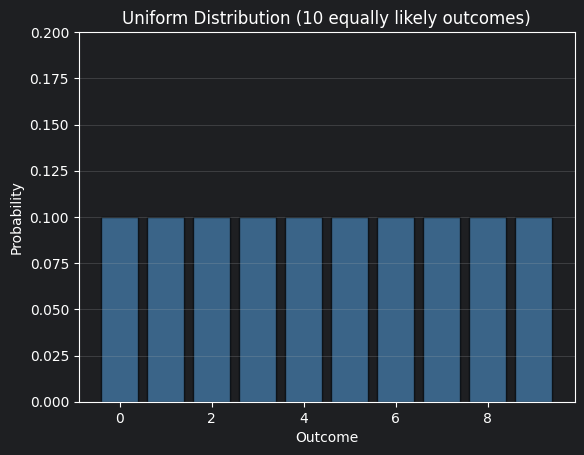

In [7]:
outcomes = 10
probs = np.ones(outcomes) / outcomes
plt.bar(range(outcomes), probs, color='steelblue', alpha=0.7, edgecolor='black')
plt.xlabel('Outcome')
plt.ylabel('Probability')
plt.title('Uniform Distribution (10 equally likely outcomes)')
plt.ylim(0, 0.2)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Bernoulli Distribution (Discrete)

A single yes/no trial. One classification decision — was the route correct or not — is Bernoulli.

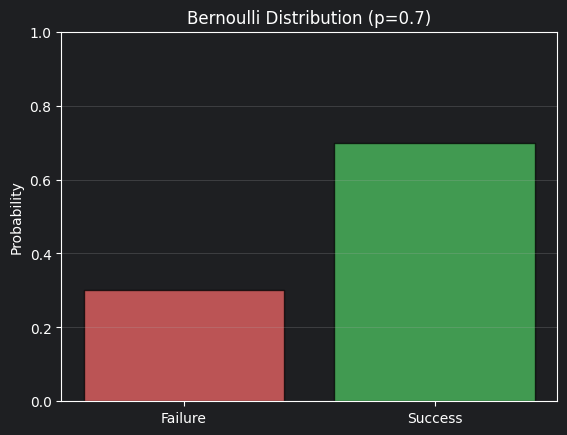

In [8]:
outcomes = ['Failure', 'Success']
probs = [0.3, 0.7]
plt.bar(outcomes, probs, color=['#ff6b6b', '#51cf66'], alpha=0.7, edgecolor='black')
plt.ylabel('Probability')
plt.title('Bernoulli Distribution (p=0.7)')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Binomial Distribution (Discrete)

Counts successes across many Bernoulli trials. How many correct routes in a batch of 20 requests?

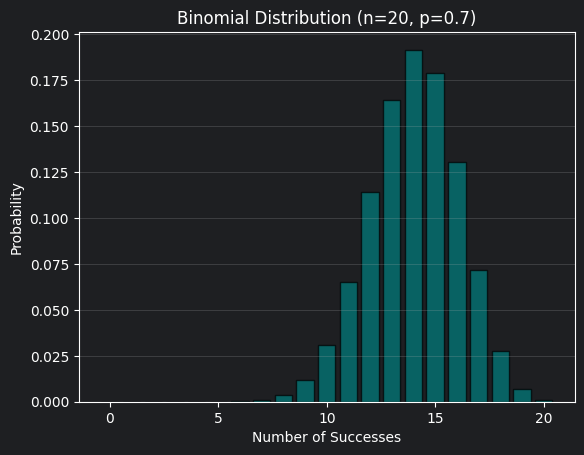

In [9]:
n, p = 20, 0.7
x = range(0, n+1)
probs = [binom.pmf(k, n, p) for k in x]
plt.bar(x, probs, color='teal', alpha=0.7, edgecolor='black')
plt.xlabel('Number of Successes')
plt.ylabel('Probability')
plt.title('Binomial Distribution (n=20, p=0.7)')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Normal (Gaussian) Distribution (Continuous)

Bell-curve. Aggregated metrics (average scores, latencies across many requests) tend to converge toward a normal distribution.

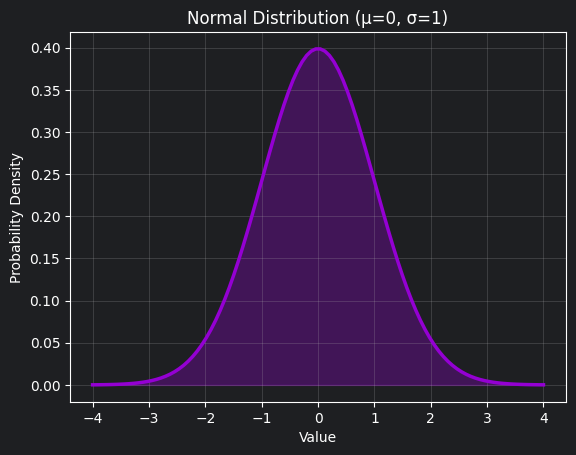

In [10]:
mu, sigma = 0, 1
x = np.linspace(-4, 4, 100)
y = norm.pdf(x, mu, sigma)
plt.plot(x, y, linewidth=2.5, color='darkviolet')
plt.fill_between(x, y, alpha=0.3, color='darkviolet')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.title('Normal Distribution (μ=0, σ=1)')
plt.grid(alpha=0.3)
plt.show()

## Exponential Distribution (Continuous)

Models waiting time between events. How long until the next escalation or incident arrives?

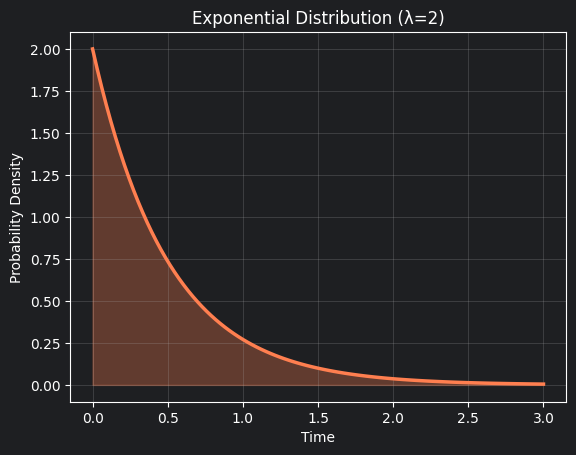

In [11]:
lam = 2
t = np.linspace(0, 3, 100)
y = expon.pdf(t, scale=1/lam)
plt.plot(t, y, linewidth=2.5, color='coral')
plt.fill_between(t, y, alpha=0.3, color='coral')
plt.xlabel('Time')
plt.ylabel('Probability Density')
plt.title('Exponential Distribution (λ=2)')
plt.grid(alpha=0.3)
plt.show()

## Poisson Distribution (Discrete)

Counts how many events happen in a fixed window. Incidents per hour, errors per 1,000 requests.

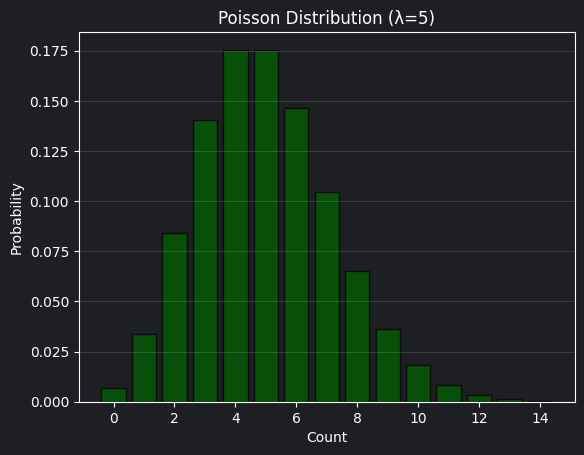

In [12]:
lam = 5
k = range(0, 15)
probs = [poisson.pmf(x, lam) for x in k]
plt.bar(k, probs, color='darkgreen', alpha=0.7, edgecolor='black')
plt.xlabel('Count')
plt.ylabel('Probability')
plt.title('Poisson Distribution (λ=5)')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Temperature Effects on Token Probability Distribution (Categorical / Discrete)

Same logits, four different temperatures. Watch how probability mass spreads as temperature rises — from sharp and decisive to near-uniform.

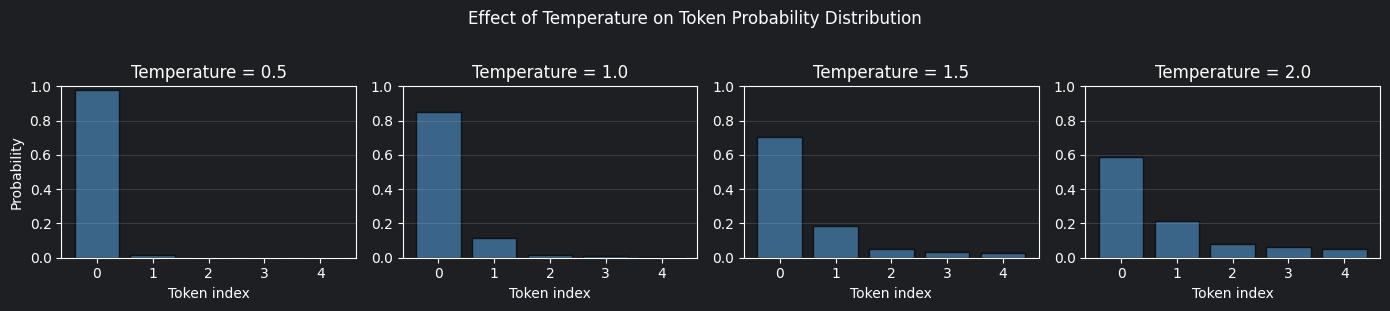

In [13]:
logits = np.array([5, 3, 1, 0.5, 0.1])

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
temperatures = [0.5, 1.0, 1.5, 2.0]

for ax, T in zip(axes, temperatures):
    probs = np.exp(logits / T) / np.sum(np.exp(logits / T))
    ax.bar(range(5), probs, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_title(f'Temperature = {T}')
    ax.set_ylim(0, 1)
    ax.set_xlabel('Token index')
    ax.set_ylabel('Probability' if T == 0.5 else '')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Effect of Temperature on Token Probability Distribution', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()